# Second impediment - images with tiny faces

## 1. Enroll tinyface users

In [ ]:
import sys; sys.path.insert(0, '..')
from src.model import get_insightface_model
from src.database import EmbeddingDB
from src.enrollment import enroll_from_folder

app = get_insightface_model('buffalo_l', ctx_id=0)
db = EmbeddingDB()

In [ ]:
results = enroll_from_folder('../data/tinyface_enrolled', app, db)
print(f'\nEnrolowanych użytkowników: {len(db)}')
print(f'Łącznie embeddingów: {sum(len(v) for v in db.get_all().values())}')

  1001: averaged 1/1 embeddings -> 1 vector stored
  1009: averaged 1/1 embeddings -> 1 vector stored
  101: averaged 2/2 embeddings -> 1 vector stored
  1010: averaged 2/2 embeddings -> 1 vector stored
  1012: averaged 5/5 embeddings -> 1 vector stored
  1019: averaged 1/1 embeddings -> 1 vector stored
  1023: averaged 2/2 embeddings -> 1 vector stored
  1024: averaged 1/1 embeddings -> 1 vector stored
  1026: averaged 3/3 embeddings -> 1 vector stored
  1028: averaged 2/2 embeddings -> 1 vector stored
  1029: averaged 3/3 embeddings -> 1 vector stored
  103: averaged 3/3 embeddings -> 1 vector stored
  1030: averaged 1/1 embeddings -> 1 vector stored
  1031: averaged 2/2 embeddings -> 1 vector stored
  1032: averaged 1/1 embeddings -> 1 vector stored
  1045: averaged 3/3 embeddings -> 1 vector stored
  105: averaged 4/4 embeddings -> 1 vector stored
  1051: averaged 3/3 embeddings -> 1 vector stored
  1053: averaged 1/1 embeddings -> 1 vector stored
  1061: averaged 1/1 embeddings ->

In [ ]:
# Podsumowanie — ilu użytkowników i ile zdjęć
import pandas as pd
df = pd.DataFrame([
    {'user': u, 'embeddings': len(db.get_user_embeddings(u))}
    for u in db.get_all_users()
])
print(df.to_string())
assert len(db) >= 80, f'Za mało użytkowników: {len(db)} < 80'

## 2. Test authentication

In [ ]:
import sys
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import auc, roc_curve, confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, str(Path('..').resolve()))

from src.model import get_insightface_model, get_embedding, cosine_similarity
from src.database import EmbeddingDB
from src.metrics import compute_far_frr, compute_roc, eer, plot_roc, plot_far_frr_vs_threshold
from src.utils import list_images

warnings.filterwarnings('ignore')

SEED             = 44
DEFAULT_THRESH   = 0.4
TEST_DIR         = Path('../data/tinyface_enrolled_test')

enrolled_users = set(db.get_all_users())
print(f'Enrolled users in DB : {len(enrolled_users)}')
print(f'Test directory       : {TEST_DIR.resolve()}')

Enrolled users in DB : 2664
Test directory       : /home/drzewo/szt_mag/face/data/tinyface_enrolled_test


In [4]:
# Collect all test images that belong to enrolled users
# Each entry: (user_id, embedding)

print('Extracting embeddings from test images...')

probes = []   # list of (user_id, embedding)

user_dirs = sorted(d for d in TEST_DIR.iterdir() if d.is_dir() and d.name in enrolled_users)

for user_dir in user_dirs:
    user_id = user_dir.name
    imgs = list_images(user_dir)
    for img_path in imgs:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        emb = get_embedding(app, img, fallback=True)
        if emb is None:
            continue
        probes.append((user_id, emb))

print(f'Total valid probes : {len(probes)}')
print(f'Users with probes  : {len({uid for uid, _ in probes})}')

if len(probes) < 500:
    print(f'WARNING: only {len(probes)} probes — spec requires >= 500. '
          'Check enrolled_test/ or run enroll.py to rebuild the split.')

Extracting embeddings from test images...
Total valid probes : 3042
Users with probes  : 2564


In [5]:
SEED             = 44
DEFAULT_THRESH   = 0.4

user_list = sorted(enrolled_users)  # stable order for reproducible random sampling
rng = random.Random(SEED)

scores       = []
labels       = []
meta         = []   # (true_user_id, matched_user_id, pair_type)

for user_id, probe_emb in probes:
    # --- Genuine ---
    refs = db.get_user_embeddings(user_id)
    if refs:
        sim = max(float(np.dot(probe_emb, ref)) for ref in refs)
        scores.append(sim)
        labels.append(1)
        meta.append((user_id, user_id, 'genuine'))

    # --- Impostor (10 random different users per probe) ---
    candidates = [u for u in user_list if u != user_id]
    for impostor_id in rng.sample(candidates, min(10, len(candidates))):
        imp_refs = db.get_user_embeddings(impostor_id)
        if imp_refs:
            sim = max(float(np.dot(probe_emb, ref)) for ref in imp_refs)
            scores.append(sim)
            labels.append(0)
            meta.append((user_id, impostor_id, 'impostor'))

scores = np.array(scores)
labels = np.array(labels)

n_genuine  = int((labels == 1).sum())
n_impostor = int((labels == 0).sum())
print(f'Genuine  pairs : {n_genuine}')
print(f'Impostor pairs : {n_impostor}')
print(f'Total          : {len(scores)}')
print(f'Balance ratio  : {n_genuine / max(n_impostor, 1):.2f} (1.0 = perfect)')

Genuine  pairs : 3042
Impostor pairs : 30420
Total          : 33462
Balance ratio  : 0.10 (1.0 = perfect)


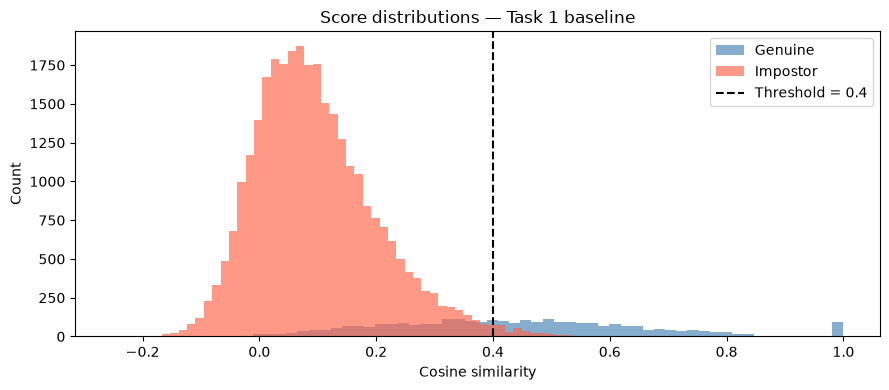

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(scores[labels == 1], bins=60, alpha=0.65, color='steelblue',  label='Genuine')
ax.hist(scores[labels == 0], bins=60, alpha=0.65, color='tomato',     label='Impostor')
ax.axvline(DEFAULT_THRESH, color='k', ls='--', lw=1.5, label=f'Threshold = {DEFAULT_THRESH}')

ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Count')
ax.set_title('Score distributions — Task 1 baseline')
ax.legend()
plt.tight_layout()

out_dir = Path('../results/task1')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'score_distributions.png', dpi=150)
plt.show()

In [7]:
far, frr, acc = compute_far_frr(scores, labels, DEFAULT_THRESH)

print(f'=== Metrics at threshold = {DEFAULT_THRESH} ===')
print(f'  FAR      : {far:.4f}  ({far*100:.2f}%)')
print(f'  FRR      : {frr:.4f}  ({frr*100:.2f}%)')
print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')

=== Metrics at threshold = 0.4 ===
  FAR      : 0.0101  (1.01%)
  FRR      : 0.4599  (45.99%)
  Accuracy : 0.9490  (94.90%)


AUC : 0.9255
EER : 0.1509  (15.09%)  at threshold = 0.2029


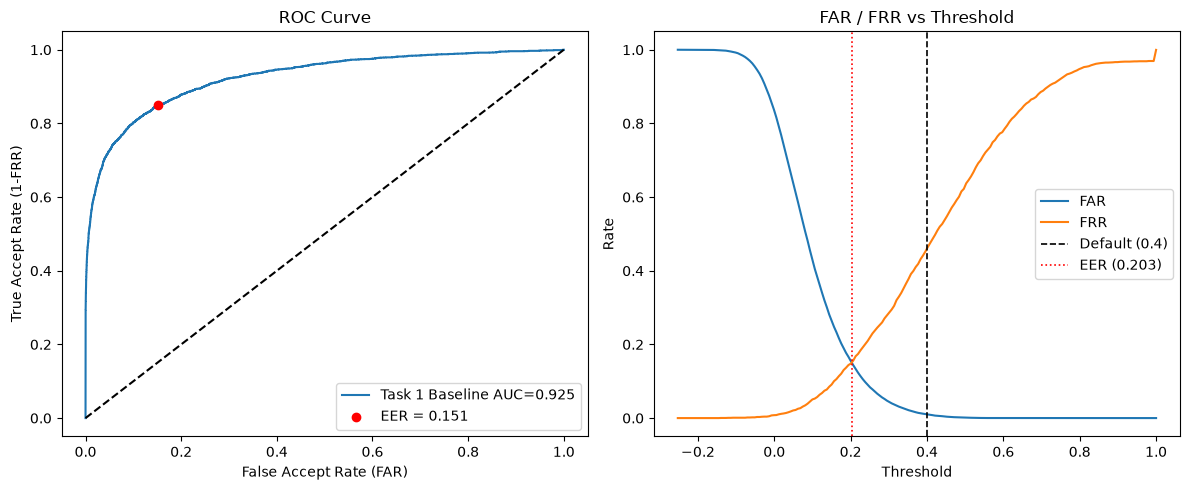

In [8]:
fpr, tpr, thresholds = compute_roc(scores, labels)
eer_val, eer_thresh  = eer(fpr, tpr, thresholds)
auc_val              = auc(fpr, tpr)

print(f'AUC : {auc_val:.4f}')
print(f'EER : {eer_val:.4f}  ({eer_val*100:.2f}%)  at threshold = {eer_thresh:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
plot_roc(fpr, tpr, ax=axes[0], label='Task 1 Baseline')
axes[0].scatter([eer_val], [1 - eer_val], color='red', zorder=5, label=f'EER = {eer_val:.3f}')
axes[0].legend()

# FAR / FRR vs threshold
plot_far_frr_vs_threshold(scores, labels, ax=axes[1])
axes[1].axvline(DEFAULT_THRESH, color='k', ls='--', lw=1.2, label=f'Default ({DEFAULT_THRESH})')
axes[1].axvline(eer_thresh,     color='r', ls=':',  lw=1.2, label=f'EER ({eer_thresh:.3f})')
axes[1].legend()

plt.tight_layout()
plt.savefig(out_dir / 'roc_and_far_frr.png', dpi=150)
plt.show()

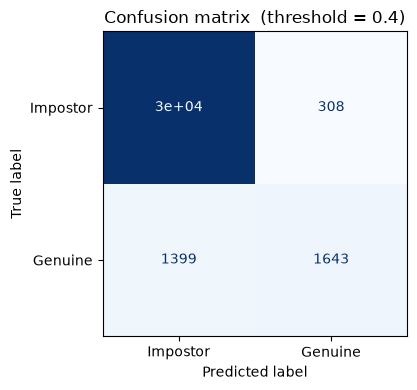

TN (correct reject)  : 30112
FP (false accept)    : 308
FN (false reject)    : 1399
TP (correct accept)  : 1643


In [9]:
decisions = (scores >= DEFAULT_THRESH).astype(int)
cm = confusion_matrix(labels, decisions)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=['Impostor', 'Genuine'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion matrix  (threshold = {DEFAULT_THRESH})')
plt.tight_layout()
plt.savefig(out_dir / 'confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN (correct reject)  : {tn}')
print(f'FP (false accept)    : {fp}')
print(f'FN (false reject)    : {fn}')
print(f'TP (correct accept)  : {tp}')